In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import root_mean_squared_error
from statsmodels.tsa.api import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from torch.distributions import Exponential
import os
from ipywidgets import interact,widgets
from statsmodels.tsa.api import Holt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
# from pmdarima.arima import
#PMDARIMA requires numpy < 2
os.chdir(r'C:\Users\dai\Downloads\Datasets\Datasets')

In [47]:
df=pd.read_csv('500820.csv')
series=df['Low Price']

In [48]:
y_train=df['Low Price'].iloc[:-12]
y_test=df['Low Price'].iloc[-12:]

In [49]:
ses=SimpleExpSmoothing(y_train)
def simple_exp(alpha):
    fit1=ses.fit(smoothing_level=alpha)
    fcast1=fit1.forecast(len(y_test))
    y_test.plot(color='pink',label='Test')
    fcast1.plot(color='purple',label='Forecast')
    rmse=root_mean_squared_error(y_test,fcast1)
    plt.title(f'RMSE = {rmse:.2f}, alpha = {alpha:.2f}')
    plt.legend(loc='best')
    plt.show()
widgets.interact(simple_exp,alpha=(0.01,1,0.01))

interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, min=0.01, step=0.01), Output()), _d…

<function __main__.simple_exp(alpha)>

In [50]:
def damped(alpha,beta,phi,exponentiality,dampness):
    holt=Holt(y_train,exponential=exponentiality,damped_trend=dampness)
    fit1=holt.fit(smoothing_level=alpha,smoothing_trend=beta,damping_trend=phi)
    fcast1=fit1.forecast(len(y_test))
    y_test.plot(color='pink',label='Test')
    fcast1.plot(color='purple',label='Forecast')
    rmse=root_mean_squared_error(y_test,fcast1)
    plt.title(f'RMSE = {rmse:.2f}, alpha = {alpha:.2f}, betas = {beta:.2f}')
    plt.legend(loc='best')
    plt.show()
widgets.interact(damped,alpha=(0.01,1,0.01),beta=(0.01,1,0.01),phi=(0.01,1,0.01),exponentiality=[True,False],dampness=[True,False])

interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, min=0.01, step=0.01), FloatSlider(v…

<function __main__.damped(alpha, beta, phi, exponentiality, dampness)>

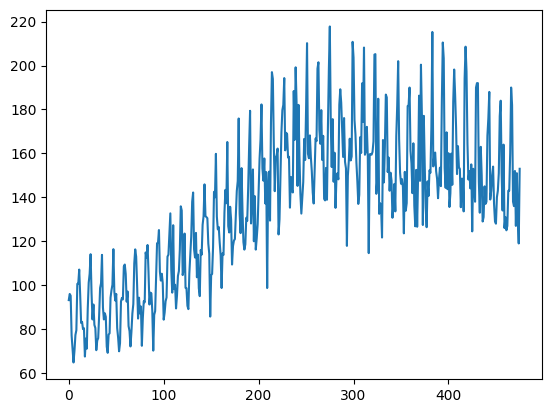

In [51]:
df=pd.read_csv('monthly-beer-production-in-austr.csv')
y_train=df['Monthly beer production']
plt.plot(y_train)
plt.show()

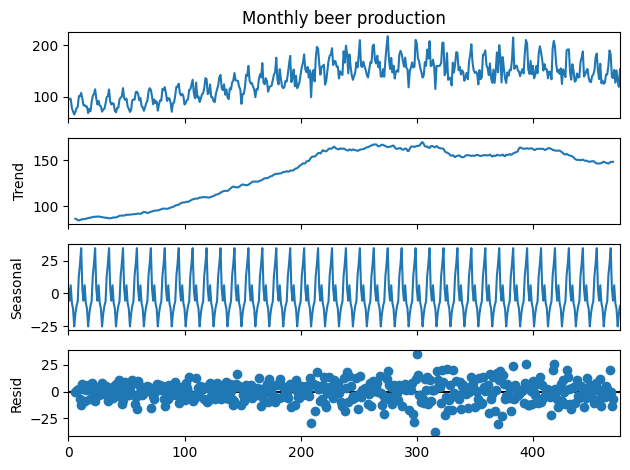

In [52]:
result=seasonal_decompose(y_train,model='additive',period=12)
result.plot()
plt.show()

In [53]:
y_train=df['Monthly beer production'].iloc[:-12]
y_test=df['Monthly beer production'].iloc[-12:]

In [54]:
def holt_both(alpha, beta, exponentiality):
    holt = Holt(y_train, exponential=exponentiality)
    fit1 = holt.fit(smoothing_level=alpha, smoothing_trend=beta)
    fcast1 = fit1.forecast(len(y_test))
    y_test.plot(color='pink',label='Test')
    fcast1.plot(color='purple',label='Forecast')
    rmse=root_mean_squared_error(y_test,fcast1)
    plt.title(f'RMSE = {rmse:.5f}, alpha = {alpha:.2f}, beta = {beta:.2f}')
    plt.legend(loc='best')
    plt.show()
widgets.interact(holt_both,alpha=(0.01,1,0.01), beta=(0.01,1,0.01), exponentiality = [True, False])

interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, min=0.01, step=0.01), FloatSlider(v…

<function __main__.holt_both(alpha, beta, exponentiality)>

In [55]:
def hw(alpha, beta, gamma, seasonality, periods=12):
    holt = ExponentialSmoothing(y_train, trend='add', seasonal=seasonality, seasonal_periods=periods)
    fit1 = holt.fit(smoothing_level=alpha, smoothing_trend=beta, smoothing_seasonal = gamma)
    fcast1 = fit1.forecast(len(y_test))
    y_test.plot(color='pink',label='Test')
    fcast1.plot(color='purple',label='Forecast')
    rmse=root_mean_squared_error(y_test,fcast1)
    plt.title(f'RMSE = {rmse:.2f}, alpha = {alpha:.2f}, beta = {beta:.2f}, gamma = {gamma:.2f}')
    plt.legend(loc='best')
    plt.show()
widgets.interact(hw,alpha=(0.01,1,0.01), beta=(0.01,1,0.01), gamma=(0.01,1,0.01), seasonality = ['add', 'mul'])

interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, min=0.01, step=0.01), FloatSlider(v…

<function __main__.hw(alpha, beta, gamma, seasonality, periods=12)>

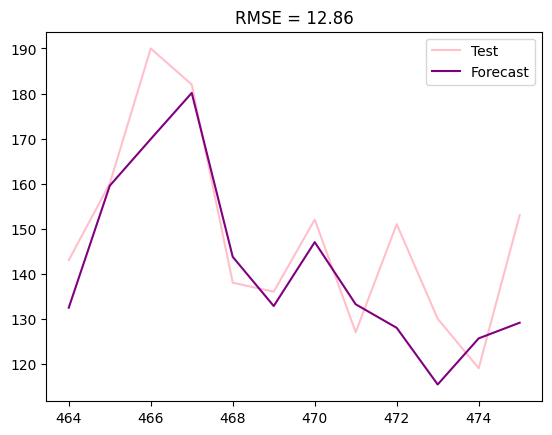

In [56]:
holt = ExponentialSmoothing(y_train, trend='add',seasonal='add',seasonal_periods=12)
fit1 = holt.fit()
# alpha,beta=fit1.params['']
fcast1 = fit1.forecast(len(y_test))
y_test.plot(color='pink',label='Test')
fcast1.plot(color='purple',label='Forecast')
rmse=root_mean_squared_error(y_test,fcast1)
plt.title(f'RMSE = {rmse:.2f}')
plt.legend(loc='best')
plt.show()

### Augmented Dicky Fuller Test

In [63]:
df = pd.read_csv('FRED-NROUST.csv')
series=df['Value']
result=adfuller(df['Value'],maxlag=10)
result[1]

np.float64(0.8679327286496534)

In [64]:
result=adfuller(df['Value'],maxlag=10)
print(f'P-Value: {result[1]:.4f}')
if result[1]<0.05:
    print('Time Series is stationary')
else:
    print('Time Series is not stationary')

P-Value: 0.8679
Time Series is not stationary


In [65]:
ord_1_diff=df['Value'].diff()
ord_1_diff=ord_1_diff.dropna()
result=adfuller(ord_1_diff,maxlag=10)
print(f'P-Value: {result[1]:.4f}')
if result[1]<0.05:
    print('Time Series is stationary')
else:
    print('Time Series is not stationary')

P-Value: 0.0004
Time Series is stationary


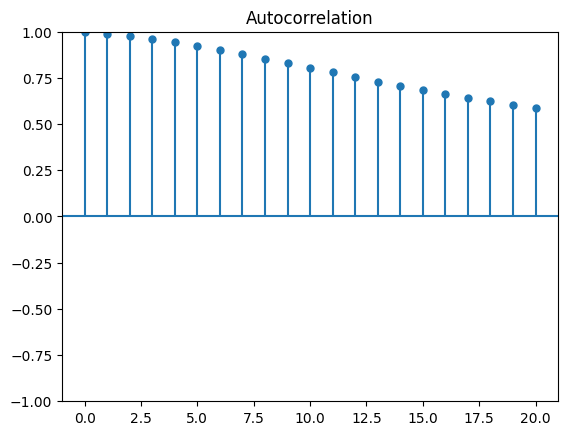

In [71]:
plot_acf(df['Value'],lags=20,alpha=None)
plt.show()

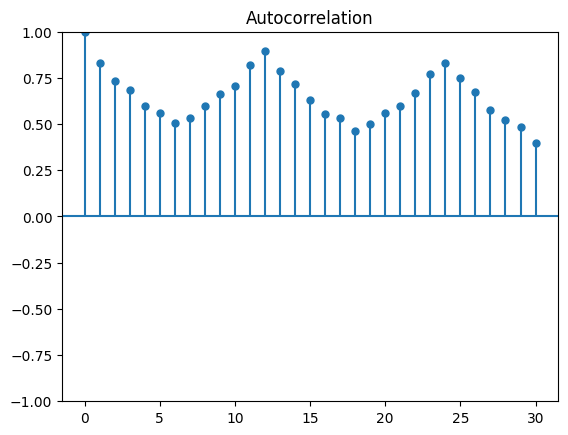

In [73]:
beer=pd.read_csv('monthly-beer-production-in-austr.csv')
plot_acf(beer['Monthly beer production'],lags=30,alpha=None)
plt.show()

In [78]:
df = pd.read_csv('FRED-NROUST.csv')
y_train=df['Value'].iloc[:-8]
y_test=df['Value'].iloc[-8:]
model=ARIMA(y_train,order=(1,1,1))

In [80]:
model_fit=model.fit()
print('Coefficients: %s'%model_fit.params)
predictions=model_fit.predict(start=len(y_train),end=len(y_train)+len(y_test)-1,dynamic=False)

Coefficients: ar.L1     0.934649
ma.L1    -0.152856
sigma2    0.000131
dtype: float64


<Axes: >

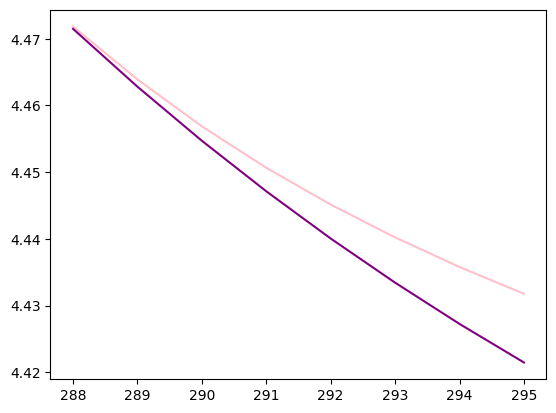

In [81]:
y_test.plot(color='pink',label='Test')
predictions.plot(color='purple',label='Forecast')

In [82]:
def arima(AR,diff,MA):
    model = ARIMA(y_train, order=(AR, diff, MA))
    model_fit = model.fit()
    print('Coefficients: %s' % model_fit.params)
    predictions = model_fit.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1, dynamic=False)
    y_test.plot(color='pink', label='Test')
    predictions.plot(color='purple', label='Forecast')
widgets.interact(arima,AR=(0,5,1), diff=(0,5,1), MA=(0,5,1))

interactive(children=(IntSlider(value=2, description='AR', max=5), IntSlider(value=2, description='diff', max=…

<function __main__.arima(AR, diff, MA)>

Coefficients: ar.L1       0.490007
ma.L1      -0.948879
sigma2    298.539527
dtype: float64


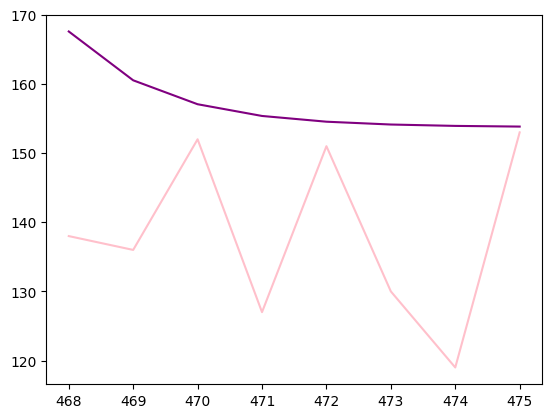

interactive(children=(IntSlider(value=2, description='AR', max=5), IntSlider(value=2, description='diff', max=…

<function __main__.arima(AR, diff, MA)>

In [84]:
df = pd.read_csv('monthly-beer-production-in-austr.csv')
y_train = df['Monthly beer production'].iloc[:-8]
y_test = df['Monthly beer production'].iloc[-8:]
model = ARIMA(y_train, order=(1, 1, 1))
model_fit = model.fit()
print('Coefficients: %s' % model_fit.params)
predictions = model_fit.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1, dynamic=False)
y_test.plot(color='pink', label='Test')
predictions.plot(color='purple', label='Forecast')


def arima(AR, diff, MA):
    model = ARIMA(y_train, order=(AR, diff, MA))
    model_fit = model.fit()
    print('Coefficients: %s' % model_fit.params)
    predictions = model_fit.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1, dynamic=False)
    y_test.plot(color='pink', label='Test')
    predictions.plot(color='purple', label='Forecast')


widgets.interact(arima, AR=(0, 5, 1), diff=(0, 5, 1), MA=(0, 5, 1))

### SARIMA

Coefficients: ar.L1       -0.159658
ma.L1       -0.884902
ar.S.L12     0.143749
ma.S.L12    -0.875921
sigma2      98.529471
dtype: float64


<Axes: title={'center': 'RMSE: 11.13419'}>

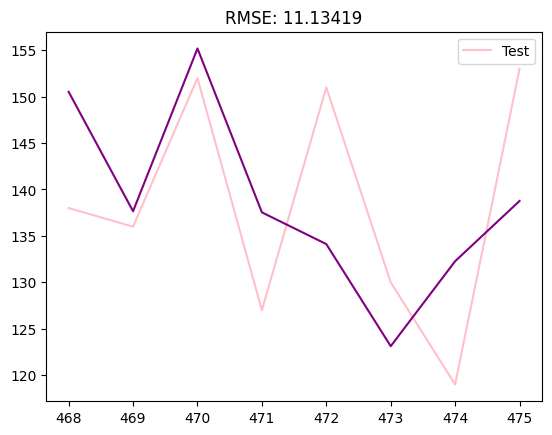

In [88]:
model=ARIMA(y_train,order=(1,1,1),seasonal_order=(1,1,1,12))
model_fit = model.fit()
print('Coefficients: %s' % model_fit.params)
predictions = model_fit.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1, dynamic=False)
y_test.plot(color='pink', label='Test')
rmse=root_mean_squared_error(y_test,predictions)
plt.title(f'RMSE: {rmse:.5f}')
plt.legend(loc='best')
predictions.plot(color='purple', label='Forecast')

In [89]:
def sarima(p,q,d,P,Q,D,s):
    model=ARIMA(y_train,order=(p,d,q),seasonal_order=(P,D,Q,s))
    model_fit = model.fit()
    print('Coefficients: %s' % model_fit.params)
    predictions = model_fit.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1, dynamic=False)
    rmse=root_mean_squared_error(y_test,predictions)
    plt.title(f'RMSE: {rmse:.5f}')
    plt.legend(loc='best')
    y_test.plot(color='pink', label='Test')
    predictions.plot(color='purple', label='Forecast')
widgets.interact(sarima, p=(0, 5, 1), q=(0, 5, 1), d=(0, 5, 1), P=(0, 5, 1), Q=(0, 5, 1), D=(0, 5, 1), s=12)

interactive(children=(IntSlider(value=2, description='p', max=5), IntSlider(value=2, description='q', max=5), …

<function __main__.sarima(p, q, d, P, Q, D, s)>

In [92]:
# df = pd.read_csv('monthly-milk-production-pounds-p.csv')
# y_train = df['Milk'].iloc[:-8]
# y_test = df['Milk'].iloc[-8:]
# model = ARIMA(y_train, order=(1, 1, 1))
# model_fit = model.fit()
# print('Coefficients: %s' % model_fit.params)
# predictions = model_fit.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1, dynamic=False)
# y_test.plot(color='pink', label='Test')
# predictions.plot(color='purple', label='Forecast')


def arima(AR, diff, MA):
    model = ARIMA(y_train, order=(AR, diff, MA))
    model_fit = model.fit()
    print('Coefficients: %s' % model_fit.params)
    predictions = model_fit.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1, dynamic=False)
    rmse=root_mean_squared_error(y_test,predictions)
    plt.title(f'RMSE: {rmse:.5f}')
    plt.legend(loc='best')
    y_test.plot(color='pink', label='Test')
    predictions.plot(color='purple', label='Forecast')


widgets.interact(arima, AR=(0, 5, 1), diff=(0, 5, 1), MA=(0, 5, 1))

interactive(children=(IntSlider(value=2, description='AR', max=5), IntSlider(value=2, description='diff', max=…

<function __main__.arima(AR, diff, MA)>

In [93]:
def sarima(p,q,d,P,Q,D,s):
    model=ARIMA(y_train,order=(p,d,q),seasonal_order=(P,D,Q,s))
    model_fit = model.fit()
    print('Coefficients: %s' % model_fit.params)
    predictions = model_fit.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1, dynamic=False)
    rmse=root_mean_squared_error(y_test,predictions)
    plt.title(f'RMSE: {rmse:.5f}')
    plt.legend(loc='best')
    y_test.plot(color='pink', label='Test')
    predictions.plot(color='purple', label='Forecast')
widgets.interact(sarima, p=(0, 5, 1), q=(0, 5, 1), d=(0, 5, 1), P=(0, 5, 1), Q=(0, 5, 1), D=(0, 5, 1), s=12)

interactive(children=(IntSlider(value=2, description='p', max=5), IntSlider(value=2, description='q', max=5), …

<function __main__.sarima(p, q, d, P, Q, D, s)>

In [94]:
bank=pd.read_csv('BUNDESBANK-BBK01_WT5511.csv')
y_train=bank['Value'].iloc[:-12]
y_test=bank['Value'].iloc[-12:]

In [96]:
def hw(alpha, beta, gamma, seasonality, periods=12):
    holt = ExponentialSmoothing(y_train, trend='add', seasonal=seasonality, seasonal_periods=periods)
    fit1 = holt.fit(smoothing_level=alpha, smoothing_trend=beta, smoothing_seasonal = gamma)
    fcast1 = fit1.forecast(len(y_test))
    y_test.plot(color='pink',label='Test')
    fcast1.plot(color='purple',label='Forecast')
    rmse=root_mean_squared_error(y_test,fcast1)
    plt.title(f'RMSE = {rmse:.2f}, alpha = {alpha:.2f}, beta = {beta:.2f}, gamma = {gamma:.2f}')
    plt.legend(loc='best')
    plt.show()
widgets.interact(hw,alpha=(0.01,1,0.01), beta=(0.01,1,0.01), gamma=(0.01,1,0.01), seasonality = ['add', 'mul'])

interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, min=0.01, step=0.01), FloatSlider(v…

<function __main__.hw(alpha, beta, gamma, seasonality, periods=12)>

In [ ]:
def arima(AR, diff, MA):
    model = ARIMA(y_train, order=(AR, diff, MA))
    model_fit = model.fit()
    print('Coefficients: %s' % model_fit.params)
    predictions = model_fit.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1, dynamic=False)
    rmse=root_mean_squared_error(y_test,predictions)
    plt.title(f'RMSE: {rmse:.5f}')
    plt.legend(loc='best')
    y_test.plot(color='pink', label='Test')
    predictions.plot(color='purple', label='Forecast')
widgets.interact(arima, AR=(0, 5, 1), diff=(0, 5, 1), MA=(0, 5, 1))

In [98]:
def sarima(p,q,d,P,Q,D,s):
    model=ARIMA(y_train,order=(p,d,q),seasonal_order=(P,D,Q,s))
    model_fit = model.fit()
    print('Coefficients: %s' % model_fit.params)
    predictions = model_fit.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1, dynamic=False)
    rmse=root_mean_squared_error(y_test,predictions)
    plt.title(f'RMSE: {rmse:.5f}')
    plt.legend(loc='best')
    y_test.plot(color='pink', label='Test')
    predictions.plot(color='purple', label='Forecast')
widgets.interact(sarima, p=(0, 5, 1), q=(0, 5, 1), d=(0, 5, 1), P=(0, 5, 1), Q=(0, 5, 1), D=(0, 5, 1), s=12)

interactive(children=(IntSlider(value=2, description='p', max=5), IntSlider(value=2, description='q', max=5), …

<function __main__.sarima(p, q, d, P, Q, D, s)>